In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib_venn

# # deal with this later...

# g = sns.FacetGrid(filtered.sample(1000), col="#CHROM", col_wrap = 5, sharex = False, row_order = ['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7','chr8', 'chr9', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 'chr21', 'chr22', 'chrX', 'chrY', 'chrM'])
# g.map(sns.histplot, "POS", binwidth=10000000)

# Summary

I ran `winnowmap` to map reads to CHM13, in accordance with Joana's pipeline (informed by HPRC). Peter and I discussed that the QC filtering/cutoffs imposed by `sniffles`, even in mosaic mode, are probably too stringent for the SVs that we're trying to capture. 

I now have two outfiles per sample:
* `{specimen}.vcf.gz` - a minimally filtered file.
  * `minsupport` = 1, `mapq` = 10, `mosaic-af-min` = 0, `mosaic-qc-strand` = False
* `{specimen}_no_qc.vcf.gz` - a completely unfiltered file.

Logfiles indicated over 10X as many SVs called in the `no-qc` file, which is a large excess. Not going to look at those files for now.

In [2]:
# Reading in the data. Many of these operations tweak some element of the file to make it easier to parse later on.
# The filtered and more easily parsable version used later in the notebook can be loaded in from 20230823_filtered.csv. 
minfilter = pd.read_table('/Users/stacyli/savio/global/scratch/stacy-l/spermSV/output/mapping/CHM13/sniffles/mosaic/single_sample/HG002_894_simulation.vcf.gz', skiprows = 72)
minfilter['RNAMES'] = minfilter['INFO'].str.extract("(?<=RNAMES=)(.+)(?=;C)")
minfilter['SVTYPE'] = minfilter['INFO'].str.extract("(?<=SVTYPE=)(\w+)(?=;)")
minfilter = pd.concat([minfilter.drop(columns=['SAMPLE', 'FORMAT']), minfilter['SAMPLE'].str.split(':', expand = True).rename(columns={0: 'GT', 1: 'GQ', 2: 'DR', 3: 'DV'})], axis = 1)
minfilter['GQ'] = minfilter['GQ'].astype('int')
minfilter['DR'] = minfilter['DR'].astype('int')
minfilter['DV'] = minfilter['DV'].astype('int')
print(minfilter.shape)
minfilter.head()

(17184, 14)


,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,RNAMES,SVTYPE,GT,GQ,DR,DV
0,chr1,36605,Sniffles2.INS.BS0,N,GGCGGCACACGCGGGTTCTCTGTGGCCAGCAGGCGGCGCTGCAGGA...,57,PASS,IMPRECISE;MOSAIC;SVTYPE=INS;SVLEN=876;END=3660...,"m84053_230601_202536_s4/227216994/ccs,m84053_2...",INS,0/1,12,71,21
1,chr1,90774,Sniffles2.INS.DS0,N,GGGGTAGGAGACCATCAGGACAAACACGTGGATACATGGAGGGGAA...,60,PASS,IMPRECISE;MOSAIC;SVTYPE=INS;SVLEN=76;END=90774...,"m84053_230601_202536_s4/232981007/ccs,m84053_2...",INS,0/0,21,15,2
2,chr1,92624,Sniffles2.DEL.1871S0,accatcaggacaaacacgtgggtacatggaggggaacaacacacac...,N,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-77;END=92701;...,m84053_230601_202536_s4/34931686/ccs,DEL,0/0,34,16,1
3,chr1,93068,Sniffles2.DEL.1873S0,ggggacagggggtaggagaccatcaggacaaacacgtggatacatg...,N,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-76;END=93144;...,m84053_230601_202536_s4/34931686/ccs,DEL,0/0,34,16,1
4,chr1,215586,Sniffles2.DEL.1878S0,gcaatggaatgcattggaatggaatgcaatggacttgaatgggatg...,N,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-52;END=215638...,m84053_230629_234400_s4/148115362/ccs,DEL,0/0,60,53,1


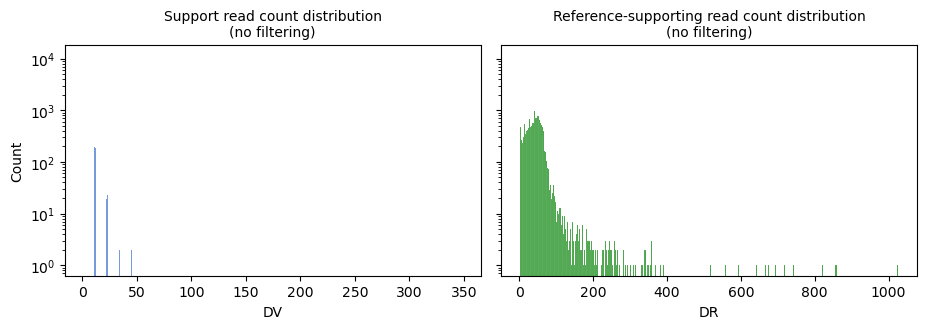

In [52]:
# understand the distribution of DV (SV supporting reads) in minfilter
fig, ax = plt.subplots(ncols = 2, figsize = (11, 3), sharey = True)

sns.set_color_codes("muted")
sns.histplot(ax = ax[0], data=minfilter, x = 'DV', stat = 'count',
            label="SV-supporting reads", color = 'b', edgecolor = 'white')
sns.histplot(ax = ax[1], data=minfilter, x = 'DR', stat = 'count',
            label="Reference-supporting reads", color = 'green', edgecolor = 'white')
ax[0].set_title("Support read count distribution\n(no filtering)", size = 10)
ax[1].set_title("Reference-supporting read count distribution\n(no filtering)", size = 10)
fig.subplots_adjust(wspace = 0.05, hspace = 0.05)
plt.yscale('log')
plt.show()

The x-axis of each plot is skewed by high-value outliers. Examining sorted values on `DV` yields more that have very high `DR` *and* `DV` counts. Examination of the top result on UCSC Genome Browser indicates that the SV candidate occurs on a centromeric region.

In [4]:
minfilter.sort_values('DV', ascending = False)

,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,RNAMES,SVTYPE,GT,GQ,DR,DV
9739,chr10,41052937,Sniffles2.INS.312SB,N,TGCTTTGTCATCTGTGCGTTCAGTTCACAGAGTTTCACCTTTCTCT...,48,PASS,PRECISE;MOSAIC;SVTYPE=INS;SVLEN=334;END=410529...,"m84053_230629_234400_s4/35984920/ccs,m84053_23...",INS,0/1,60,859,348
9740,chr10,41062786,Sniffles2.INS.315SB,N,TGCTTTGTCATCTGTGCGTTCAGTTCACAGAGTTTCACCTTTCTCT...,49,PASS,PRECISE;MOSAIC;SVTYPE=INS;SVLEN=336;END=410627...,"m84053_230601_202536_s4/169348415/ccs,m84053_2...",INS,0/1,60,694,281
11102,chr13,17014631,Sniffles2.INS.788SD,N,AAAAGAAAGGTTCAACTCTGTTAGTTGAGGACACACATCACAAAGA...,59,PASS,PRECISE;MOSAIC;SVTYPE=INS;SVLEN=171;END=170146...,"m84053_230629_234400_s4/157680080/ccs,m84053_2...",INS,0/1,19,565,162
11037,chr13,14378498,Sniffles2.INS.51CSD,N,ATTATGTACTGTACATAATATATTAAATCGCCCAAATACATATTGT...,58,PASS,PRECISE;MOSAIC;SVTYPE=INS;SVLEN=125;END=143784...,"m84053_230601_202536_s4/20059560/ccs,m84053_23...",INS,0/1,60,369,149
11038,chr13,14379723,Sniffles2.INS.51ESD,N,TAAAATATCAAAGTACCCAAAATATATATTGTAAACTGTACATAAA...,59,PASS,PRECISE;MOSAIC;SVTYPE=INS;SVLEN=84;END=1437972...,"m84053_230601_202536_s4/20059560/ccs,m84053_23...",INS,0/1,60,370,147
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6507,chr9,17344290,Sniffles2.DEL.2208S8,GAAAATGAGATTTATTTATTAAAACATAACTGCATTATACATTTCT...,N,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-56;END=173443...,m84053_230601_202536_s4/34080220/ccs,DEL,0/0,60,73,1
6508,chr9,17522613,Sniffles2.DEL.2209S8,cttagtattactatgccatgtggttaaagtcaatgaaaaactacca...,N,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-155;END=17522...,m84053_230629_234400_s4/144901212/ccs,DEL,0/0,60,39,1
6509,chr9,17750451,Sniffles2.DUP.5D61S8,N,<DUP>,60,PASS,PRECISE;MOSAIC;SVTYPE=DUP;SVLEN=24844265;END=4...,m84053_230629_234400_s4/245433102/ccs,DUP,0/0,60,58,1
6510,chr9,18239887,Sniffles2.DEL.2210S8,TGTTTGAGGCTCTCCCCATTCAGCCTTAACTGGTCTTTTCAGATTT...,N,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-61;END=182399...,m84053_230601_202536_s4/145752615/ccs,DEL,0/0,60,46,1


Examining what the plot above looks like when setting reasonable max values for DV & DR (let's say the 99.5th percentile for each).

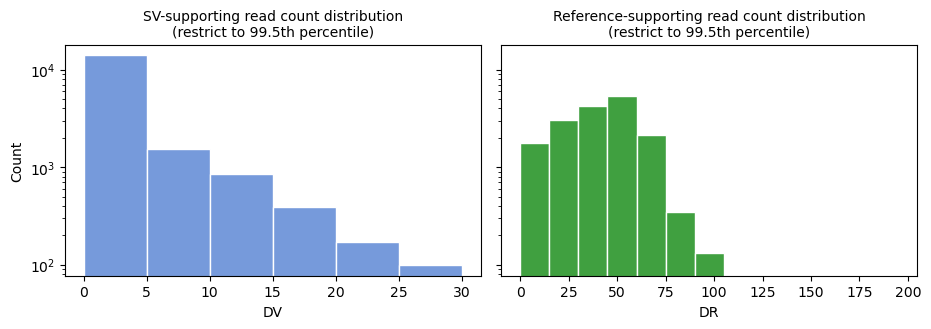

In [53]:
fig, ax = plt.subplots(ncols = 2, figsize = (11, 3), sharey = True)

sns.set_color_codes("muted")
sns.histplot(ax = ax[0], data=minfilter.query("DV <= " + str(np.percentile(minfilter['DV'], 99.5))), x = 'DV', stat = 'count',
            label="SV-supporting reads", color = 'b', edgecolor = 'white', bins = np.arange(0,np.percentile(minfilter['DV'], 99.5), 5))
sns.histplot(ax = ax[1], data=minfilter.query("DR <= " + str(np.percentile(minfilter['DR'], 99.5))), x = 'DR', stat = 'count',
            label="Reference-supporting reads", color = 'green', edgecolor = 'white', bins = np.arange(0,np.percentile(minfilter['DR'], 99.5), 15))
ax[0].set_title("SV-supporting read count distribution\n(restrict to 99.5th percentile)", size = 10)
ax[1].set_title("Reference-supporting read count distribution\n(restrict to 99.5th percentile)", size = 10)
fig.subplots_adjust(wspace = 0.05, hspace = 0.05)
plt.yscale('log')
plt.show()

Now what if we implement `DV <= 4` (we expect max 4 reads supporting a de novo SV) + reference support counts max 99.5th percentile as filtering?

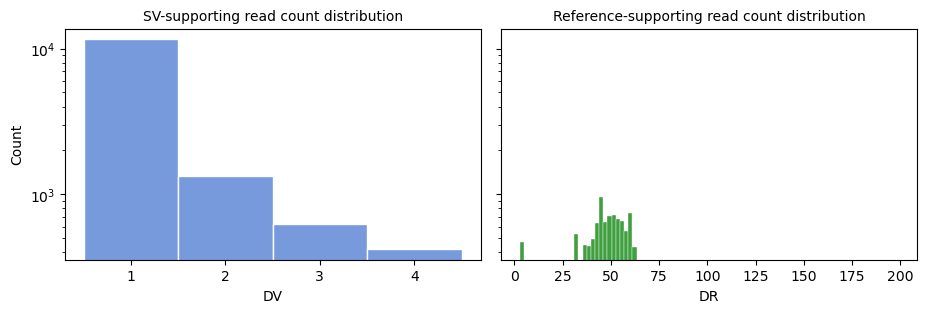

In [44]:
fig, ax = plt.subplots(ncols = 2, figsize = (11, 3), sharey = True)

sns.set_color_codes("muted")
sns.histplot(ax = ax[0], data=minfilter.query("DV <= 4 & DR <= " + str(np.percentile(minfilter['DR'], 99.5))), x = 'DV', stat = 'count',
            label="SV-supporting reads", color = 'b', edgecolor = 'white', binrange = (1,5), binwidth = 1)
ax[0].set_xticks([1.5, 2.5, 3.5, 4.5], [1, 2, 3, 4])
sns.histplot(ax = ax[1], data=minfilter.query("DV <= 4 & DR <= " + str(np.percentile(minfilter['DR'], 99.5))), x = 'DR', stat = 'count',
            label="Reference-supporting reads", color = 'green', edgecolor = 'white')
ax[0].set_title("SV-supporting read count distribution", size = 10)
ax[1].set_title("Reference-supporting read count distribution", size = 10)
fig.subplots_adjust(wspace = 0.05, hspace = 0.05)
plt.yscale('log')
plt.show()

In [48]:
# what's the max/mean/med of DR above?
print("Max:", minfilter.query("DV <= 4 & DR <= " + str(np.percentile(minfilter['DR'], 99.5)))['DR'].max())
print("Mean:", minfilter.query("DV <= 4 & DR <= " + str(np.percentile(minfilter['DR'], 99.5)))['DR'].mean())
print("Stdev:", minfilter.query("DV <= 4 & DR <= " + str(np.percentile(minfilter['DR'], 99.5)))['DR'].std())
print("Median:", minfilter.query("DV <= 4 & DR <= " + str(np.percentile(minfilter['DR'], 99.5)))['DR'].median())

Max: 199
Mean: 43.01439312567132
Stdev: 20.412868444956093
Median: 45.0


Lastly, same filter as above except sub in the mean + 1.5 std value of `DR = 45` as the filtering on DR instead of 99.5th percentile.

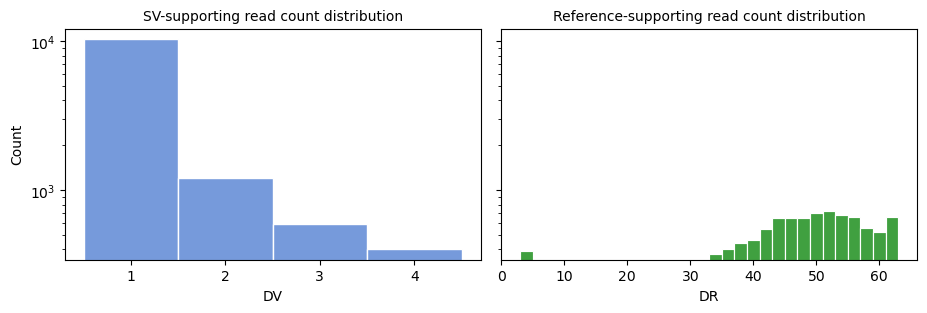

In [51]:
# understand the distribution of DV (SV supporting reads) in minfilter
fig, ax = plt.subplots(ncols = 2, figsize = (11, 3), sharey = True)

sns.set_color_codes("muted")
sns.histplot(ax = ax[0], data=minfilter.query("DV <= 4 & DR <= 63"), x = 'DV', stat = 'count',
            label="SV-supporting reads", color = 'b', edgecolor = 'white', binrange = (1,5), binwidth = 1)
ax[0].set_xticks([1.5, 2.5, 3.5, 4.5], [1, 2, 3, 4])
sns.histplot(ax = ax[1], data=minfilter.query("DV <= 4 & DR <= 63"), x = 'DR', stat = 'count',
            label="Reference-supporting reads", color = 'green', edgecolor = 'white')
ax[0].set_title("SV-supporting read count distribution", size = 10)
ax[1].set_title("Reference-supporting read count distribution", size = 10)
fig.subplots_adjust(wspace = 0.05, hspace = 0.05)
plt.yscale('log')
plt.show()

**Genome region filters:** Some SVs can be meaningful around peri-centromeric and peri-telomeric regions. However, SVs with extremely high coverage in the surrounding regions are likely being erroneously mapped due to repetitive elements. `sniffles` does provide support for minimum coverage cutoffs, but not maximum (probably because people generally like high coverage). 

Using annotations of centromeric satellites + telomeric regions for region-based exclusion is the simplest, but how can I be sure that we're not losing important things? I'll probably need to just **do the intersect/exclusion and find out.**

After a lot of thinking, I don't think that implementing a binomial distribution probability check is quite right here.

Under our assumptions, each read represents a snapshot of a single sperm cell. Each sperm cell is derived from the following events:
1. 2N spermatogonium (germ cell) divides to regenerate itself and produce a 2N primary spermatocyte.
2. 2N primary spermatocyte undergoes recombination and division (meiosis I) to yield two 1N secondary spermatocytes.
3. 1N secondary spermatocytes undergo division (meiosis II) to yield two 1N spermatids.
4. Spermatids undergo maturation through (later?) spermatogenesis.

Reference image below is from Wikipedia.
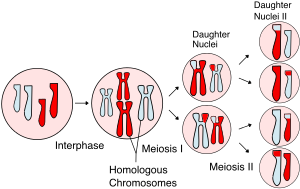!

A binomial distribution wouldn't be the right way to understand the probability of a SV occurring, because we would need to use estimated rate(s) of SV occurrence as the event probability. Those rates are drawn from surveys of SVs in living individuals, so it's an underestimation of the probable true rate (as many SVs are incompatible with life). Moreover, the rate is not uniform across the genome.

**Would Bayesian inference be more suitable?** I'm not sure how to pick the likelihood function, and it doesn't fix the problem of SV rate varying across the genome. 

# Implementing read count & QUAL filters

In the meantime, I'm going to tentatively set query filters at `DV <= 1` and `DR >= 30 & DR <= 70` as a very broad and general approach to picking candidates that represent single-cell dnSV events.

I'm also going to implement a `QUAL`-based filtered. The `sniffles` paper, describing the `QUAL` field:

```
The quality value is summarized as the mean mapping quality of supporting reads.
```

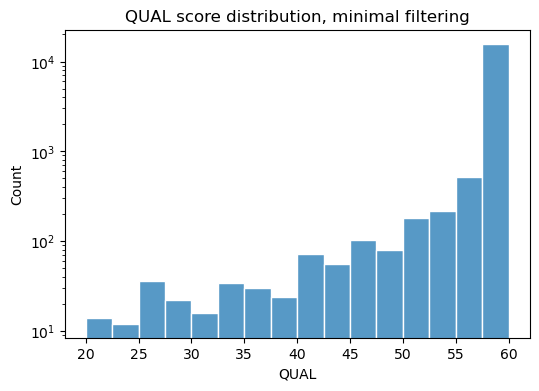

In [5]:
# understand the distribution of QUAL scores with minimal filtering
fig, ax = plt.subplots(figsize = (6, 4))

sns.set_color_codes("muted")
sns.histplot(data=minfilter, x = 'QUAL', stat = 'count',
            label="QUAL scores", edgecolor = 'white')
ax.set_title("QUAL score distribution, minimal filtering")
plt.yscale('log')
plt.show()

It looks like the majority of SV candidates are "high quality" (defined arbitrarily as `QUAL` >= 50, as the last `QUAL` filter provided by Nicolas was `QUAL` >= 30).

Below, implementing the proposed filters based on `DV`, `DR`, and `QUAL`.

In [6]:
# Evaluating attrition of SV candidates with each step.
filtered = minfilter.query("DV == 1 & DR >= 30 & DR <= 70 & QUAL >= 50")
print("Original number of SV candidates:", minfilter.shape[0])
print("Remaining after DV == 1 filter:", minfilter.query("DV == 1").shape[0])
print("Remaining after DR >= 30 filter:", minfilter.query("DV == 1 & DR >= 30").shape[0])
print("Remaining after DR <= 70 filter:", minfilter.query("DV == 1 & DR >= 30 & DR <= 70").shape[0])
print("Remaining after QUAL >= 50 filter:", minfilter.query("DV == 1 & DR >= 30 & DR <= 70 & QUAL >= 50").shape[0])

Original number of SV candidates: 17184
Remaining after DV == 1 filter: 11616
Remaining after DR >= 30 filter: 9365
Remaining after DR <= 70 filter: 8783
Remaining after QUAL >= 50 filter: 8768


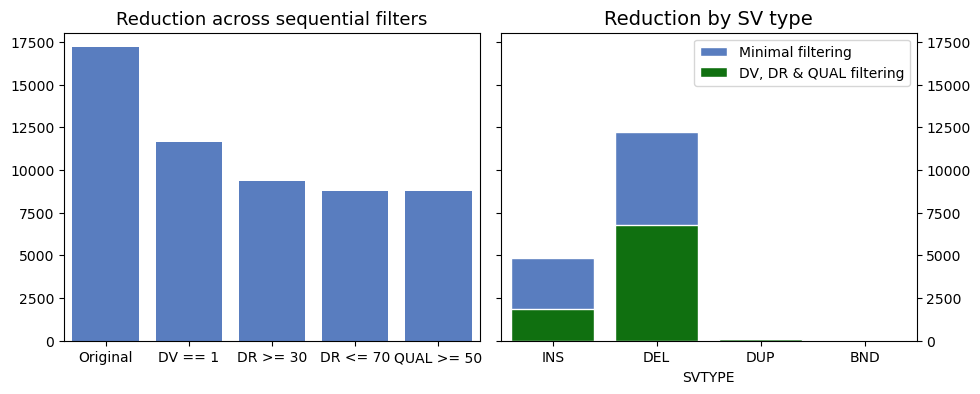

In [7]:
# understand the distribution of SVs before and after read+QUAL filtering
fig, ax = plt.subplots(ncols = 2, figsize = (11, 4), sharey = True)
sns.set_color_codes("muted")

# left
sns.barplot(ax = ax[0], x = ["Original", "DV == 1", "DR >= 30", "DR <= 70", "QUAL >= 50"], 
            y = [17184, 11616, 9365, 8783, 8768],
            color = 'b')
ax[0].set_title("Reduction across sequential filters", size = 13)
# right
sns.countplot(ax = ax[1], data=minfilter, x = 'SVTYPE',
            label="Minimal filtering", color = 'b', edgecolor = 'white',
            order = ["INS", "DEL", "DUP", "BND"])
sns.countplot(ax = ax[1], data=filtered, x = 'SVTYPE',
            label="DV, DR & QUAL filtering", color = 'green', edgecolor = 'white',
            order = ["INS", "DEL", "DUP", "BND"])
ax[1].set_title("Reduction by SV type", size = 14)
ax[1].tick_params(left = True, right = True, labelright = True)
ax[1].set_ylabel("")
ax[1].legend()

fig.subplots_adjust(wspace = 0.05, hspace = 0.05)

# Examining recall of HG002 germline SVs

Now, to look at the recall of SVs from `HG002`. Need to clean up the `RNAMES` values to make them easier to interpret: left them as-is in the original `filtered` table for integrity, but here, we're not interested in specific read ID, only the specimen.

In [8]:
# First, check if the flow cells named here are correct
# 894 has two flow cells: 
# 1) m84053_230601_202536_s4
# 2) m84053_230629_234400_s4
# HG002 has one flow cell:
# 1) m84039_230117_233243_s1
filtered['RNAMES'].str.extract("(.+)(?=\/\d)")[0].unique()

array(['m84053_230629_234400_s4', 'm84053_230601_202536_s4',
       'm84039_230117_233243_s1'], dtype=object)

Nice, okay. Time to rename them so they're less annoying to parse later + save the `filtered` table to a `.csv` for backup later.

In [9]:
filtered['RNAMES'] = filtered['RNAMES'].str.replace("m84053_230601_202536_s4", "894")
filtered['RNAMES'] = filtered['RNAMES'].str.replace("m84053_230629_234400_s4", "894")
filtered['RNAMES'] = filtered['RNAMES'].str.replace("m84039_230117_233243_s1", "HG002")
filtered.to_csv("filtered.csv", index = False)
filtered.head()

/var/folders/d1/_d4s2fqs7_z4dhbkbh6b02xw0000gn/T/ipykernel_76330/834028697.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered['RNAMES'] = filtered['RNAMES'].str.replace("m84053_230601_202536_s4", "894")
/var/folders/d1/_d4s2fqs7_z4dhbkbh6b02xw0000gn/T/ipykernel_76330/834028697.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered['RNAMES'] = filtered['RNAMES'].str.replace("m84053_230629_234400_s4", "894")
/var/folders/d1/_d4s2fqs7_z4dhbkbh6b02xw0000gn/T/ipykernel_76330/834028697.py:3: Setti

,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,RNAMES,SVTYPE,GT,GQ,DR,DV
4,chr1,215586,Sniffles2.DEL.1878S0,gcaatggaatgcattggaatggaatgcaatggacttgaatgggatg...,N,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-52;END=215638...,894/148115362/ccs,DEL,0/0,60,53,1
5,chr1,218571,Sniffles2.DEL.1879S0,tcgaaaggaatggaatggaatggaatggaatggaatggaatggaat...,N,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-71;END=218642...,894/134088549/ccs,DEL,0/0,60,51,1
6,chr1,218804,Sniffles2.DEL.187AS0,aatggaatcgacccgaatggaatggaatggaatggaatggaatgga...,N,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-66;END=218870...,894/134088549/ccs,DEL,0/0,60,51,1
7,chr1,219836,Sniffles2.DEL.187BS0,aatggaatgaacccgaatggaatggaatggaatggaatggaatgga...,N,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-71;END=219907...,894/206832977/ccs,DEL,0/0,60,52,1
8,chr1,267875,Sniffles2.DEL.187DS0,tctaataaggaatatcaataaagaaataaaaattattttaaaaaac...,N,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-159;END=26803...,894/142739248/ccs,DEL,0/0,60,65,1


Alright, breaking down how many SVs are from `HG002` versus `894`...

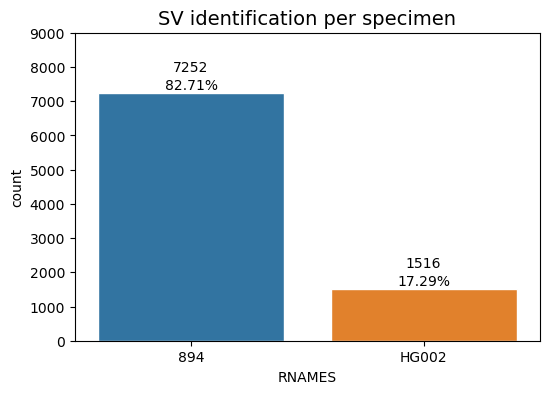

In [10]:
# understand the distribution of SV types before and after read+QUAL filtering
fig, ax = plt.subplots(figsize = (6, 4))

filtered_plot = filtered.copy()
filtered_plot['RNAMES'] = filtered_plot['RNAMES'].str.extract("(.+)(?=\/\d)")[0]
filtered_plot['RNAMES'].replace({"m84053_230601_202536_s4": "894",  "m84053_230629_234400_s4": "894", "m84039_230117_233243_s1": "HG002"}, inplace = True)

sns.set_color_codes("muted")
sns.countplot(data=filtered_plot, x = 'RNAMES',
            label="SVs by specimen", edgecolor = 'white')
ax.set(ylim=(0, 9000))
ax.bar_label(ax.containers[0], padding = 13)
ax.bar_label(ax.containers[0], labels = [f"{np.round(x, 4)*100}%" for x in [filtered_plot.query("RNAMES == '894'").shape[0]/filtered_plot.shape[0], filtered_plot.query("RNAMES == 'HG002'").shape[0]/filtered_plot.shape[0]]])
ax.set_title("SV identification per specimen", size = 14)
plt.show()

Now, time to look at what germline SVs in HG002 are actually called by `sniffles`.

For reference, the only filter parameter set was `mapQ = 20`, which is already default `sniffles` behavior.


In [12]:
germline = pd.read_table('/Users/stacyli/savio/global/scratch/stacy-l/spermSV/output/mapping/CHM13/sniffles/standard/single_sample/HG002.vcf.gz', skiprows = 72)
germline['RNAMES'] = germline['INFO'].str.extract("(?<=RNAMES=)(.+)(?=;C)")
germline['RNAMES'] = germline['RNAMES'].str.replace("m84039_230117_233243_s1", "HG002")
germline['SVTYPE'] = germline['INFO'].str.extract("(?<=SVTYPE=)(\w+)(?=;)")
germline = pd.concat([germline.drop(columns=['SAMPLE', 'FORMAT']), germline['SAMPLE'].str.split(':', expand = True).rename(columns={0: 'GT', 1: 'GQ', 2: 'DR', 3: 'DV'})], axis = 1)
germline['GQ'] = germline['GQ'].astype('int')
germline['DR'] = germline['DR'].astype('int')
germline['DV'] = germline['DV'].astype('int')

# save a copy for parsing later
# compressing because large file
germline.to_csv('germline.csv.gz', index = False, compression = 'gzip')

print(germline.shape)
germline.head()

(36776, 14)


,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,RNAMES,SVTYPE,GT,GQ,DR,DV
0,chr1,3635,Sniffles2.DEL.16B4S0,ccctcttgctcacagtgtagtggcagcacgcccgcctgctggcagc...,N,60,PASS,PRECISE;SVTYPE=DEL;SVLEN=-62;END=3697;SUPPORT=...,"HG002/235082663/ccs,HG002/30807480/ccs,HG002/1...",DEL,0/1,60,16,22
1,chr1,4729,Sniffles2.DEL.16B5S0,cacacaactaatcactcaaaatcatccttacactaaaaatgctaaa...,N,57,PASS,PRECISE;SVTYPE=DEL;SVLEN=-337;END=5066;SUPPORT...,"HG002/210634283/ccs,HG002/142151040/ccs,HG002/...",DEL,0/1,60,25,13
2,chr1,11670,Sniffles2.DEL.16B6S0,GTCCCTCTGTCTCTGCCAACCAGTTAACCTGCTGCTTCCTGGAGGG...,N,60,PASS,PRECISE;SVTYPE=DEL;SVLEN=-59;END=11729;SUPPORT...,"HG002/235082663/ccs,HG002/30807480/ccs,HG002/1...",DEL,0/1,60,21,22
3,chr1,18082,Sniffles2.INS.1S0,N,AGAAGGAATAAGACGGGCCGGGTGCGGTGGCTCACGCCTGTAATCC...,60,PASS,PRECISE;SVTYPE=INS;SVLEN=315;END=18082;SUPPORT...,"HG002/74976573/ccs,HG002/118818109/ccs,HG002/1...",INS,0/1,60,13,13
4,chr1,24101,Sniffles2.DEL.16B9S0,catcttacacagcaatgaggcacgtgtggaaactgcgacactcaca...,N,60,PASS,IMPRECISE;SVTYPE=DEL;SVLEN=-1128;END=25229;SUP...,"HG002/55710083/ccs,HG002/141100667/ccs,HG002/1...",DEL,0/1,32,10,6


I tested some of the filters used for `filtered` (`HG002` only) on `germline` before the merge, but realized that it isn't comparable or necessary.

In [19]:
# joining without specific position as a param
# here, filtered (DR, DV, QUAL filtered) and germline non-filtered

intersect = pd.merge(filtered[filtered['RNAMES'].str.contains('HG002')], germline, how = 'inner', on = ["#CHROM", "REF", "ALT", "SVTYPE"])
intersect

,#CHROM,POS_x,ID_x,REF,ALT,QUAL_x,FILTER_x,INFO_x,RNAMES_x,SVTYPE,...,POS_y,ID_y,QUAL_y,FILTER_y,INFO_y,RNAMES_y,GT_y,GQ_y,DR_y,DV_y
0,chr1,3184814,Sniffles2.DEL.197ES0,GTCTCCTCCCACAATGGCCCAGGTGTCTCCTCCCACAATGGCCCAG...,N,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-216;END=31850...,HG002/67241562/ccs,DEL,...,3184814,Sniffles2.DEL.1787S0,60,PASS,PRECISE;SVTYPE=DEL;SVLEN=-216;END=3185030;SUPP...,"HG002/131339983/ccs,HG002/40571767/ccs,HG002/9...",1/1,55,0,20
1,chr1,3312035,Sniffles2.DEL.198BS0,gcctgggtctctgtgccatctcgacctaacgcaggtcgctctgtgg...,N,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-150;END=33121...,HG002/49612229/ccs,DEL,...,3312035,Sniffles2.DEL.1790S0,60,PASS,PRECISE;SVTYPE=DEL;SVLEN=-150;END=3312185;SUPP...,"HG002/59446681/ccs,HG002/184423528/ccs,HG002/1...",0/1,60,17,15
2,chr1,3511635,Sniffles2.INS.C9S0,N,ACTGCCGACGGGGAGGGCCTGGAGTTGCAGGACATGTCACAGAAAG...,60,PASS,PRECISE;MOSAIC;SVTYPE=INS;SVLEN=1298;END=35116...,HG002/219942613/ccs,INS,...,3511635,Sniffles2.INS.A5S0,60,PASS,IMPRECISE;SVTYPE=INS;SVLEN=1298;END=3511635;SU...,"HG002/90968404/ccs,HG002/219942613/ccs,HG002/1...",0/1,60,13,15
3,chr1,4677080,Sniffles2.INS.DAS0,N,ACACATACACACATACTAACACATACACACACTAACACATACACAC...,60,PASS,PRECISE;MOSAIC;SVTYPE=INS;SVLEN=56;END=4677080...,HG002/29166059/ccs,INS,...,4677080,Sniffles2.INS.B8S0,60,PASS,PRECISE;SVTYPE=INS;SVLEN=56;END=4677080;SUPPOR...,"HG002/123930985/ccs,HG002/68026765/ccs,HG002/1...",1/1,60,1,39
4,chr1,4850994,Sniffles2.DEL.19B6S0,AGAAACACAACGCAGAATGCAGGATGATGGAGAAACACAAAGCAGA...,N,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-150;END=48511...,HG002/47843066/ccs,DEL,...,4850994,Sniffles2.DEL.17B8S0,60,PASS,PRECISE;SVTYPE=DEL;SVLEN=-150;END=4851144;SUPP...,"HG002/97522090/ccs,HG002/144838096/ccs,HG002/1...",0/1,60,20,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
941,chr21,34867559,Sniffles2.DEL.EE5S17,tgcctcggcctcccaaagtgctgggattacaggcatgagccactgt...,N,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-362;END=34867...,HG002/222500718/ccs,DEL,...,34867559,Sniffles2.DEL.AE8S17,60,PASS,PRECISE;SVTYPE=DEL;SVLEN=-362;END=34867921;SUP...,"HG002/190776248/ccs,HG002/22807698/ccs,HG002/2...",0/1,60,17,20
942,chr21,35971789,Sniffles2.DEL.EEAS17,aaaaggccatgctgttgggaggccgaggcgggcggatcacaaggtc...,N,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-280;END=35972...,HG002/45156927/ccs,DEL,...,35971789,Sniffles2.DEL.AEDS17,60,PASS,PRECISE;SVTYPE=DEL;SVLEN=-280;END=35972069;SUP...,"HG002/160171762/ccs,HG002/45354932/ccs,HG002/1...",0/1,60,15,18
943,chr21,36140279,Sniffles2.INS.55DS17,N,ATGATGGTTCCAGCCCAAGTGAGCACTCCCTCACAGATTCCAGCCC...,60,PASS,PRECISE;MOSAIC;SVTYPE=INS;SVLEN=106;END=361402...,HG002/244715323/ccs,INS,...,36140279,Sniffles2.INS.3DDS17,60,PASS,PRECISE;SVTYPE=INS;SVLEN=106;END=36140279;SUPP...,"HG002/157750238/ccs,HG002/184684561/ccs,HG002/...",0/1,60,23,21
944,chr21,43223924,Sniffles2.INS.5B1S17,N,CAACACAGAGACACACAGCCCGCCACGGCCTCAGCAGCACAGAGAC...,60,PASS,PRECISE;MOSAIC;SVTYPE=INS;SVLEN=496;END=432239...,HG002/70652053/ccs,INS,...,43223924,Sniffles2.INS.427S17,60,PASS,PRECISE;SVTYPE=INS;SVLEN=496;END=43223924;SUPP...,"HG002/70652053/ccs,HG002/243532327/ccs,HG002/6...",0/1,60,22,16


The above table seems to indicate that about half of the SVs derived from `HG002` in `filtered` are also found in `germline`, but not all of them. That makes sense, because the parameters for SVs in `filtered` are `DV` == 1 only. These would be culled in `germline` because of how the standard calling mode works.

Time to validate that these are shared calls: below, checks that the singular read name in `RNAMES_x` from `filtered` is present in the longer list of reads supporting calls in `germline`.

In [24]:
intersect['READMATCH'] = intersect.apply(lambda x: x.RNAMES_x in x.RNAMES_y, axis = 1)
# save a copy for future access
intersect.to_csv("intersect.csv", index = False)

intersect

,#CHROM,POS_x,ID_x,REF,ALT,QUAL_x,FILTER_x,INFO_x,RNAMES_x,SVTYPE,...,ID_y,QUAL_y,FILTER_y,INFO_y,RNAMES_y,GT_y,GQ_y,DR_y,DV_y,READMATCH
0,chr1,3184814,Sniffles2.DEL.197ES0,GTCTCCTCCCACAATGGCCCAGGTGTCTCCTCCCACAATGGCCCAG...,N,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-216;END=31850...,HG002/67241562/ccs,DEL,...,Sniffles2.DEL.1787S0,60,PASS,PRECISE;SVTYPE=DEL;SVLEN=-216;END=3185030;SUPP...,"HG002/131339983/ccs,HG002/40571767/ccs,HG002/9...",1/1,55,0,20,True
1,chr1,3312035,Sniffles2.DEL.198BS0,gcctgggtctctgtgccatctcgacctaacgcaggtcgctctgtgg...,N,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-150;END=33121...,HG002/49612229/ccs,DEL,...,Sniffles2.DEL.1790S0,60,PASS,PRECISE;SVTYPE=DEL;SVLEN=-150;END=3312185;SUPP...,"HG002/59446681/ccs,HG002/184423528/ccs,HG002/1...",0/1,60,17,15,True
2,chr1,3511635,Sniffles2.INS.C9S0,N,ACTGCCGACGGGGAGGGCCTGGAGTTGCAGGACATGTCACAGAAAG...,60,PASS,PRECISE;MOSAIC;SVTYPE=INS;SVLEN=1298;END=35116...,HG002/219942613/ccs,INS,...,Sniffles2.INS.A5S0,60,PASS,IMPRECISE;SVTYPE=INS;SVLEN=1298;END=3511635;SU...,"HG002/90968404/ccs,HG002/219942613/ccs,HG002/1...",0/1,60,13,15,True
3,chr1,4677080,Sniffles2.INS.DAS0,N,ACACATACACACATACTAACACATACACACACTAACACATACACAC...,60,PASS,PRECISE;MOSAIC;SVTYPE=INS;SVLEN=56;END=4677080...,HG002/29166059/ccs,INS,...,Sniffles2.INS.B8S0,60,PASS,PRECISE;SVTYPE=INS;SVLEN=56;END=4677080;SUPPOR...,"HG002/123930985/ccs,HG002/68026765/ccs,HG002/1...",1/1,60,1,39,True
4,chr1,4850994,Sniffles2.DEL.19B6S0,AGAAACACAACGCAGAATGCAGGATGATGGAGAAACACAAAGCAGA...,N,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-150;END=48511...,HG002/47843066/ccs,DEL,...,Sniffles2.DEL.17B8S0,60,PASS,PRECISE;SVTYPE=DEL;SVLEN=-150;END=4851144;SUPP...,"HG002/97522090/ccs,HG002/144838096/ccs,HG002/1...",0/1,60,20,20,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
941,chr21,34867559,Sniffles2.DEL.EE5S17,tgcctcggcctcccaaagtgctgggattacaggcatgagccactgt...,N,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-362;END=34867...,HG002/222500718/ccs,DEL,...,Sniffles2.DEL.AE8S17,60,PASS,PRECISE;SVTYPE=DEL;SVLEN=-362;END=34867921;SUP...,"HG002/190776248/ccs,HG002/22807698/ccs,HG002/2...",0/1,60,17,20,True
942,chr21,35971789,Sniffles2.DEL.EEAS17,aaaaggccatgctgttgggaggccgaggcgggcggatcacaaggtc...,N,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-280;END=35972...,HG002/45156927/ccs,DEL,...,Sniffles2.DEL.AEDS17,60,PASS,PRECISE;SVTYPE=DEL;SVLEN=-280;END=35972069;SUP...,"HG002/160171762/ccs,HG002/45354932/ccs,HG002/1...",0/1,60,15,18,True
943,chr21,36140279,Sniffles2.INS.55DS17,N,ATGATGGTTCCAGCCCAAGTGAGCACTCCCTCACAGATTCCAGCCC...,60,PASS,PRECISE;MOSAIC;SVTYPE=INS;SVLEN=106;END=361402...,HG002/244715323/ccs,INS,...,Sniffles2.INS.3DDS17,60,PASS,PRECISE;SVTYPE=INS;SVLEN=106;END=36140279;SUPP...,"HG002/157750238/ccs,HG002/184684561/ccs,HG002/...",0/1,60,23,21,True
944,chr21,43223924,Sniffles2.INS.5B1S17,N,CAACACAGAGACACACAGCCCGCCACGGCCTCAGCAGCACAGAGAC...,60,PASS,PRECISE;MOSAIC;SVTYPE=INS;SVLEN=496;END=432239...,HG002/70652053/ccs,INS,...,Sniffles2.INS.427S17,60,PASS,PRECISE;SVTYPE=INS;SVLEN=496;END=43223924;SUPP...,"HG002/70652053/ccs,HG002/243532327/ccs,HG002/6...",0/1,60,22,16,True


In [21]:
# arbitrarily chose #CHROM as the column to make this more readable
intersect.groupby("READMATCH").count()['#CHROM']

READMATCH
False     62
True     884
Name: #CHROM, dtype: int64

It looks like the majority of shared calls in `germline` include the HG002 read in `filtered` as a support read, but not all of them. That's a little confusing, because a read that supports an SV call in mosaic mode (less stringent support standards) should support an SV call in standard mode.

In [22]:
# Double checking manually...
print(intersect[intersect['READMATCH'] == False].iloc[0]['RNAMES_x'])
print(intersect[intersect['READMATCH'] == False].iloc[0]['RNAMES_y'])

HG002/165284725/ccs
HG002/41223630/ccs,HG002/101386613/ccs,HG002/138153108/ccs,HG002/3869905/ccs,HG002/23528454/ccs,HG002/101193295/ccs,HG002/202052786/ccs,HG002/226758510/ccs,HG002/136254696/ccs,HG002/181864211/ccs,HG002/92604308/ccs,HG002/170786968/ccs,HG002/94245588/ccs,HG002/49612265/ccs,HG002/156242172/ccs,HG002/167839737/ccs,HG002/144381175/ccs,HG002/114693386/ccs,HG002/209848999/ccs
